# Gesamtübersicht: alle Aufgaben, Modelle und Ansätze

Verdichtet die komplette Auswertung in wenige Grafiken für die Projektarbeit. Kennzahl ist durchgängig die **abgeglichene Genauigkeit** (schema-getreu, zeilenzahl-tolerant); die regelbasierte Baseline dient als Referenz.

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from reporting import compare

runs, direct = compare.load_all(seed=1)
g  = compare.codegen_by_strategy(runs)  # (Aufgabe,Modell,Strategie) -> abgegl. Genauigkeit
dm = compare.direct_matrix(direct)      # Direkt-Lauf je (Aufgabe,Modell)
bl = compare.baseline_series(runs)      # regelbasierte Baseline je Aufgabe
print(f"Code-Gen-Läufe: {len(runs)} | Direkt-Läufe: {len(direct)}")
print(f"Grafiken werden zusätzlich als PNG gespeichert unter: {compare.FIG_DIR}")

Code-Gen-Läufe: 441 | Direkt-Läufe: 36
Grafiken werden zusätzlich als PNG gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


## 1 · Große Heatmap – alles auf einen Blick

Neun Aufgaben (Zeilen) gegen alle vier Modelle in beiden Modi plus Baseline (Spalten). Die weißen Trennlinien teilen Code-Generierung | Direkt-Verarbeitung | Baseline. Gespeichert als `figures/uebersicht_heatmap.png`.

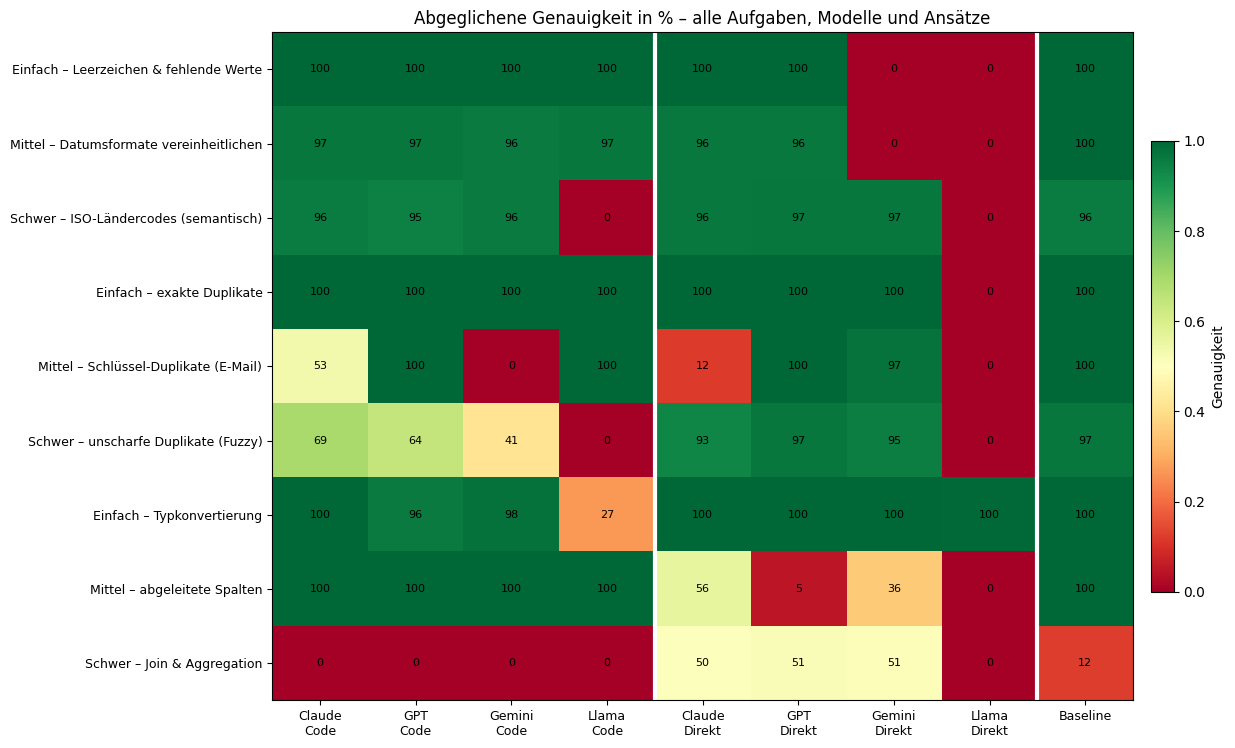

In [2]:
fig, M = compare.overview_heatmap(runs, direct); plt.show()

## 2 · Ansätze je Kategorie

Mittlere abgeglichene Genauigkeit je Kategorie und Ansatz (`figures/uebersicht_modi.png`).

,Code-Gen. (beste Strategie),Direkt-Verarbeitung,Baseline
Kategorie,,,
Datenbereinigung,89.3,56.9,98.5
Duplikaterkennung,69.0,66.2,99.0
Datentransformation,60.1,54.1,70.7


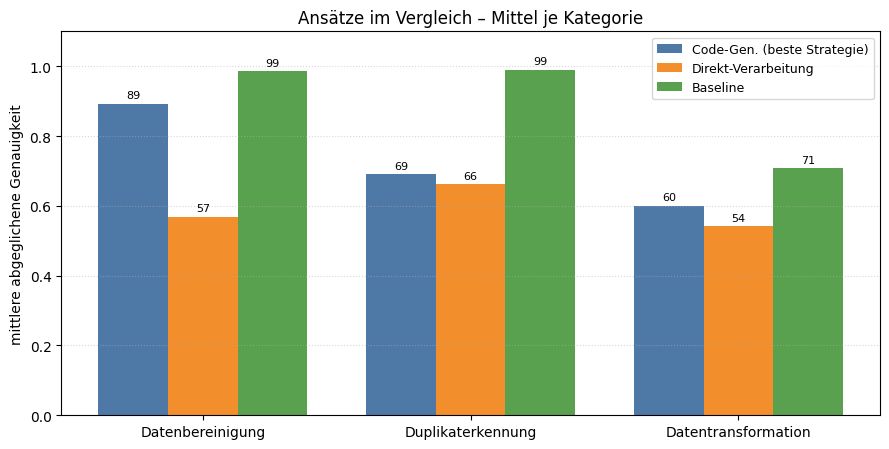

In [3]:
fig, S = compare.mode_summary(runs, direct)
display((S * 100).round(1)); plt.show()

## 3 · Tabellarische Gesamtmatrix

In [4]:
M = compare.full_matrix(runs, direct)
display((M * 100).round(1))

,Claude\nCode,GPT\nCode,Gemini\nCode,Llama\nCode,Claude\nDirekt,GPT\nDirekt,Gemini\nDirekt,Llama\nDirekt,Baseline
Einfach – Leerzeichen & fehlende Werte,100.0,100.0,100.0,100.0,100.0,100.0,0.1,0.0,100.0
Mittel – Datumsformate vereinheitlichen,96.5,96.5,95.9,96.5,96.4,96.1,0.3,0.0,100.0
Schwer – ISO-Ländercodes (semantisch),95.6,94.6,95.8,0.0,96.4,96.5,96.5,0.0,95.5
Einfach – exakte Duplikate,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0
Mittel – Schlüssel-Duplikate (E-Mail),53.3,100.0,0.0,100.0,11.8,99.8,97.3,0.0,100.0
Schwer – unscharfe Duplikate (Fuzzy),69.4,64.3,41.5,0.0,93.5,96.5,95.0,0.0,96.9
Einfach – Typkonvertierung,100.0,95.9,97.9,26.7,100.0,100.0,100.0,99.6,100.0
Mittel – abgeleitete Spalten,100.0,100.0,100.0,100.0,56.0,5.0,35.9,0.0,100.0
Schwer – Join & Aggregation,0.0,0.2,0.0,0.0,50.4,51.2,50.8,0.0,12.1


## 4 · Kernaussagen

- **Unscharfe Duplikate (Fuzzy)** – der stärkste Befund für die Direkt-Verarbeitung:
  Sie erreicht ~93–97 % (auf Baseline-Niveau), während die **Code-Generierung** je
  nach Prompt-Strategie stark schwankt und deutlich darunter bleibt (~40–70 %). Die
  Ähnlichkeitslogik lässt sich kaum zuverlässig in Code gießen, das Modell entscheidet
  aber direkt pro Fall zuverlässig.
- **Semantische Länder-Vereinheitlichung (ISO-Codes)** – hier sind **alle drei
  Ansätze nahezu gleichauf** (~95–97 %): Das nötige Weltwissen bringt das Modell auch
  in einer Code-Zuordnungstabelle unter, sodass Code-Generierung, Direkt-Verarbeitung
  und Baseline vergleichbar abschneiden. Semantik allein bedeutet also nicht
  automatisch einen Vorteil der Direkt-Verarbeitung.
- **Formalisierbare Aufgaben** (exakte Duplikate, Typkonvertierung): alle Ansätze
  hoch; die regelbasierte Baseline ist ebenbürtig.
- **Große Ergebnistabellen** (abgeleitete Spalten, Join & Aggregation): Die
  **Code-Generierung** ist im Vorteil, weil der erzeugte Code alle Zeilen
  deterministisch verarbeitet, während die Direkt-Verarbeitung am Ausgabe-Token-Limit
  abgeschnitten wird.
- Das **lokale Modell** (Llama) fällt im Direkt-Modus bei größeren Tabellen aus
  (Kontext-/Ausgabegrenze) und ist dort nicht praxistauglich.
- Die **Prompt-Strategie** ist gerade bei den schwierigen Aufgaben ein erheblicher
  Faktor (siehe Kategorie-Notebooks); die schema-angereicherte Variante ist wegen
  häufiger, unnötiger Typkonvertierungen fragil und wird separat betrachtet.